In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_products_dataset.csv to olist_products_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

In [ ]:
orders.head()
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [ ]:
df = orders.merge(order_items, on='order_id')

In [ ]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('month')['price'].sum()
monthly_revenue

,price
month,
2016-09,267.36
2016-10,49507.66
2016-12,10.90
2017-01,120312.87
2017-02,247303.02
2017-03,374344.30
2017-04,359927.23
2017-05,506071.14
2017-06,433038.60


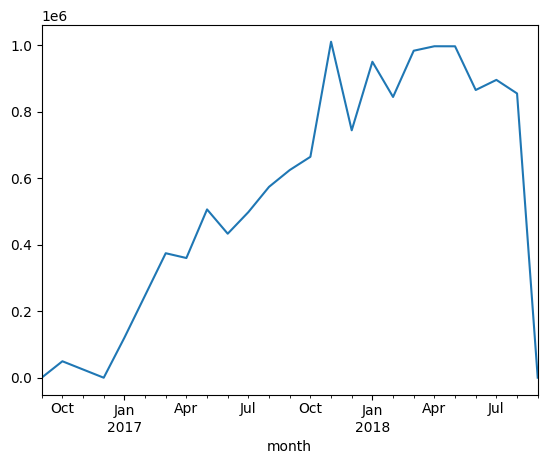

In [ ]:
monthly_revenue.plot()
plt.show()

In [ ]:
top_customers = df.groupby('customer_id')['price'].sum().sort_values(ascending=False).head(10)
top_customers

,price
customer_id,
1617b1357756262bfa56ab541c47bc16,13440.0
ec5b2ba62e574342386871631fafd3fc,7160.0
c6e2731c5b391845f6800c97401a43a9,6735.0
f48d464a0baaea338cb25f816991ab1f,6729.0
3fd6777bbce08a352fddd04e4a7cc8f6,6499.0
05455dfa7cd02f13d132aa7a6a9729c6,5934.6
df55c14d1476a9a3467f131269c2477f,4799.0
24bbf5fd2f2e1b359ee7de94defc4a15,4690.0
e0a2412720e9ea4f26c1ac985f6a7358,4599.9


In [ ]:
top_products = df.groupby('product_id')['price'].count().sort_values(ascending=False).head(10)
top_products

,price
product_id,
aca2eb7d00ea1a7b8ebd4e68314663af,527
99a4788cb24856965c36a24e339b6058,488
422879e10f46682990de24d770e7f83d,484
389d119b48cf3043d311335e499d9c6b,392
368c6c730842d78016ad823897a372db,388
53759a2ecddad2bb87a079a1f1519f73,373
d1c427060a0f73f6b889a5c7c61f2ac4,343
53b36df67ebb7c41585e8d54d6772e08,323
154e7e31ebfa092203795c972e5804a6,281


In [ ]:
orders_per_month = df.groupby('month')['order_id'].nunique()
orders_per_month

,order_id
month,
2016-09,3
2016-10,308
2016-12,1
2017-01,789
2017-02,1733
2017-03,2641
2017-04,2391
2017-05,3660
2017-06,3217


In [ ]:
aov = df.groupby('order_id')['price'].sum().mean()
aov

np.float64(137.7540763788945)

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1194
order_delivered_customer_date,2454
order_estimated_delivery_date,0
order_item_id,0
product_id,0


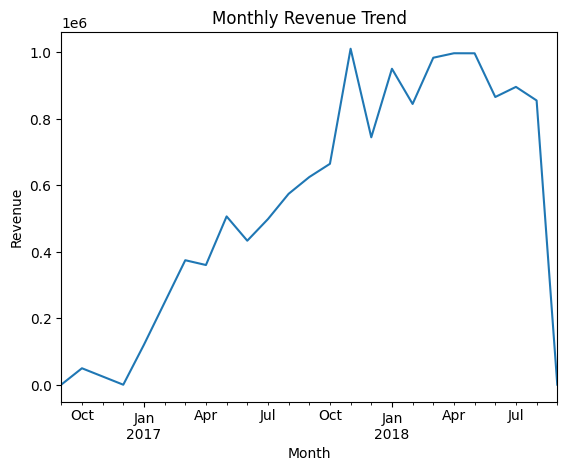

In [ ]:
monthly_revenue.plot(title='Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()